In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import plotly.express as px
from sklearn.ensemble import IsolationForest
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [2]:
train_set = pd.read_csv("/kaggle/input/dataset/emnist-balanced-train.csv")
test_set = pd.read_csv("/kaggle/input/dataset/emnist-balanced-test.csv")

In [3]:
train_set.head()

,45,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.524,0.525,0.526,0.527,0.528,0.529,0.530,0.531,0.532,0.533
0,36,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,43,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,42,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112799 entries, 0 to 112798
Columns: 785 entries, 45 to 0.533
dtypes: int64(785)
memory usage: 675.6 MB


In [5]:
print(f"Train set shape:  {train_set.shape}")
print(f"Test set shape:  {test_set.shape}")

Train set shape:  (112799, 785)
Test set shape:  (18799, 785)


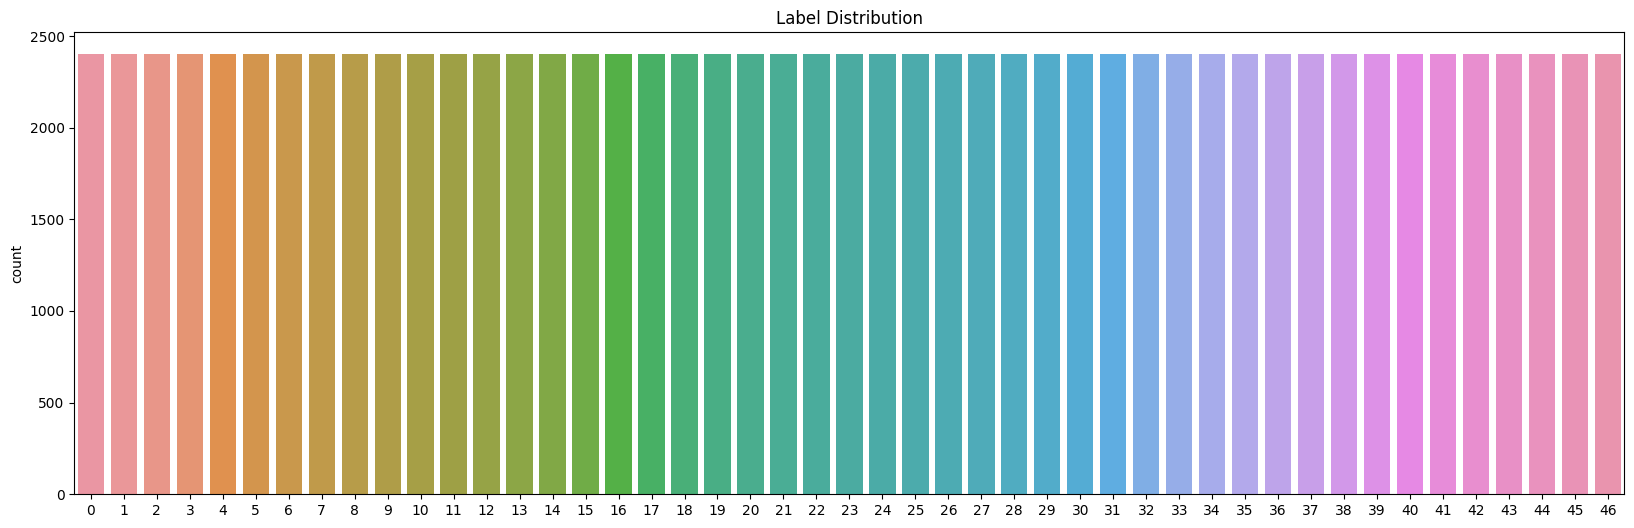

In [6]:
# Check the label distribution
labels = train_set.iloc[:, 0].values
plt.figure(figsize=(20, 6))
sns.countplot(x=labels)
plt.title("Label Distribution")
plt.show()

In [7]:
# Feature Scaling
x_train = np.array(train_set.iloc[:, 1:].values)
y_train = np.array(train_set.iloc[:, 0].values)
x_test = np.array(test_set.iloc[:, 1:].values)
y_test = np.array(test_set.iloc[:, 0].values)

In [8]:
# Normalize pixel values to the range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape for CNN input
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

# One-hot encode the labels
y_train = to_categorical(y_train, 47)
y_test = to_categorical(y_test, 47)

In [9]:
# Split the training data into train and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)


In [10]:
# 1. 3D PCA Visualization
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(x_train.reshape(x_train.shape[0], -1))

fig = px.scatter_3d(x=X_train_pca[:, 0], y=X_train_pca[:, 1], z=X_train_pca[:, 2], color=y_train.argmax(axis=1).astype(str))
fig.show()


/opt/conda/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.

/opt/conda/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.



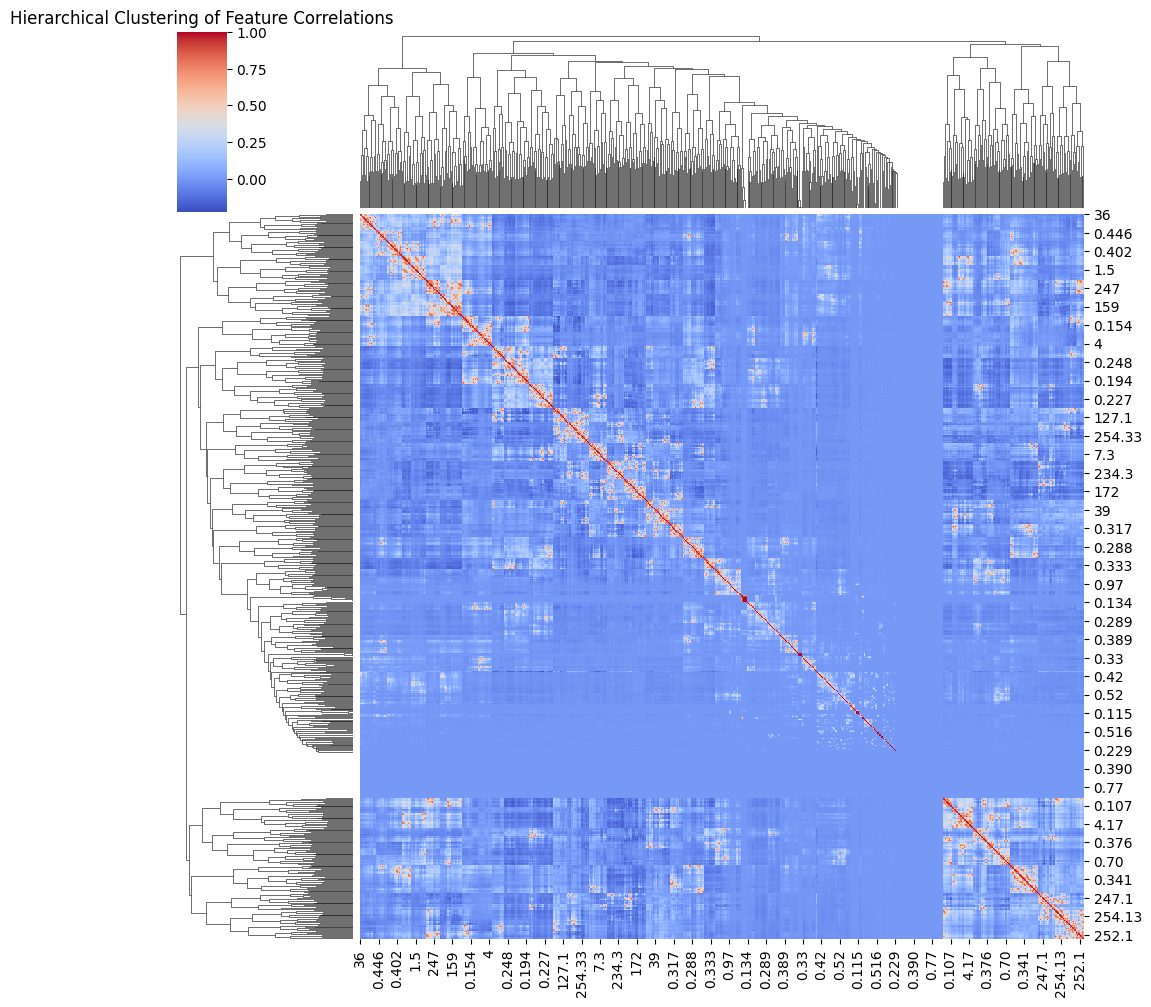

In [11]:
# 2. Hierarchical Clustering with Correlation Heatmap

# Compute correlation matrix
corr = train_set.corr()

# Fill NaN values and replace infinite values
corr = corr.fillna(0)

# Plot the heatmap with hierarchical clustering
sns.clustermap(corr, method='average', cmap='coolwarm', metric="euclidean")
plt.title('Hierarchical Clustering of Feature Correlations')
plt.show()


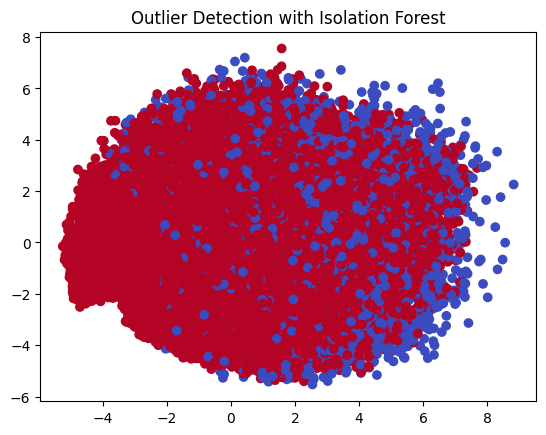

In [12]:
# 3. Outlier Detection using Isolation Forest
clf = IsolationForest(contamination=0.1)
outliers = clf.fit_predict(x_train.reshape(x_train.shape[0], -1))

plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=outliers, cmap='coolwarm')
plt.title('Outlier Detection with Isolation Forest')
plt.show()


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version

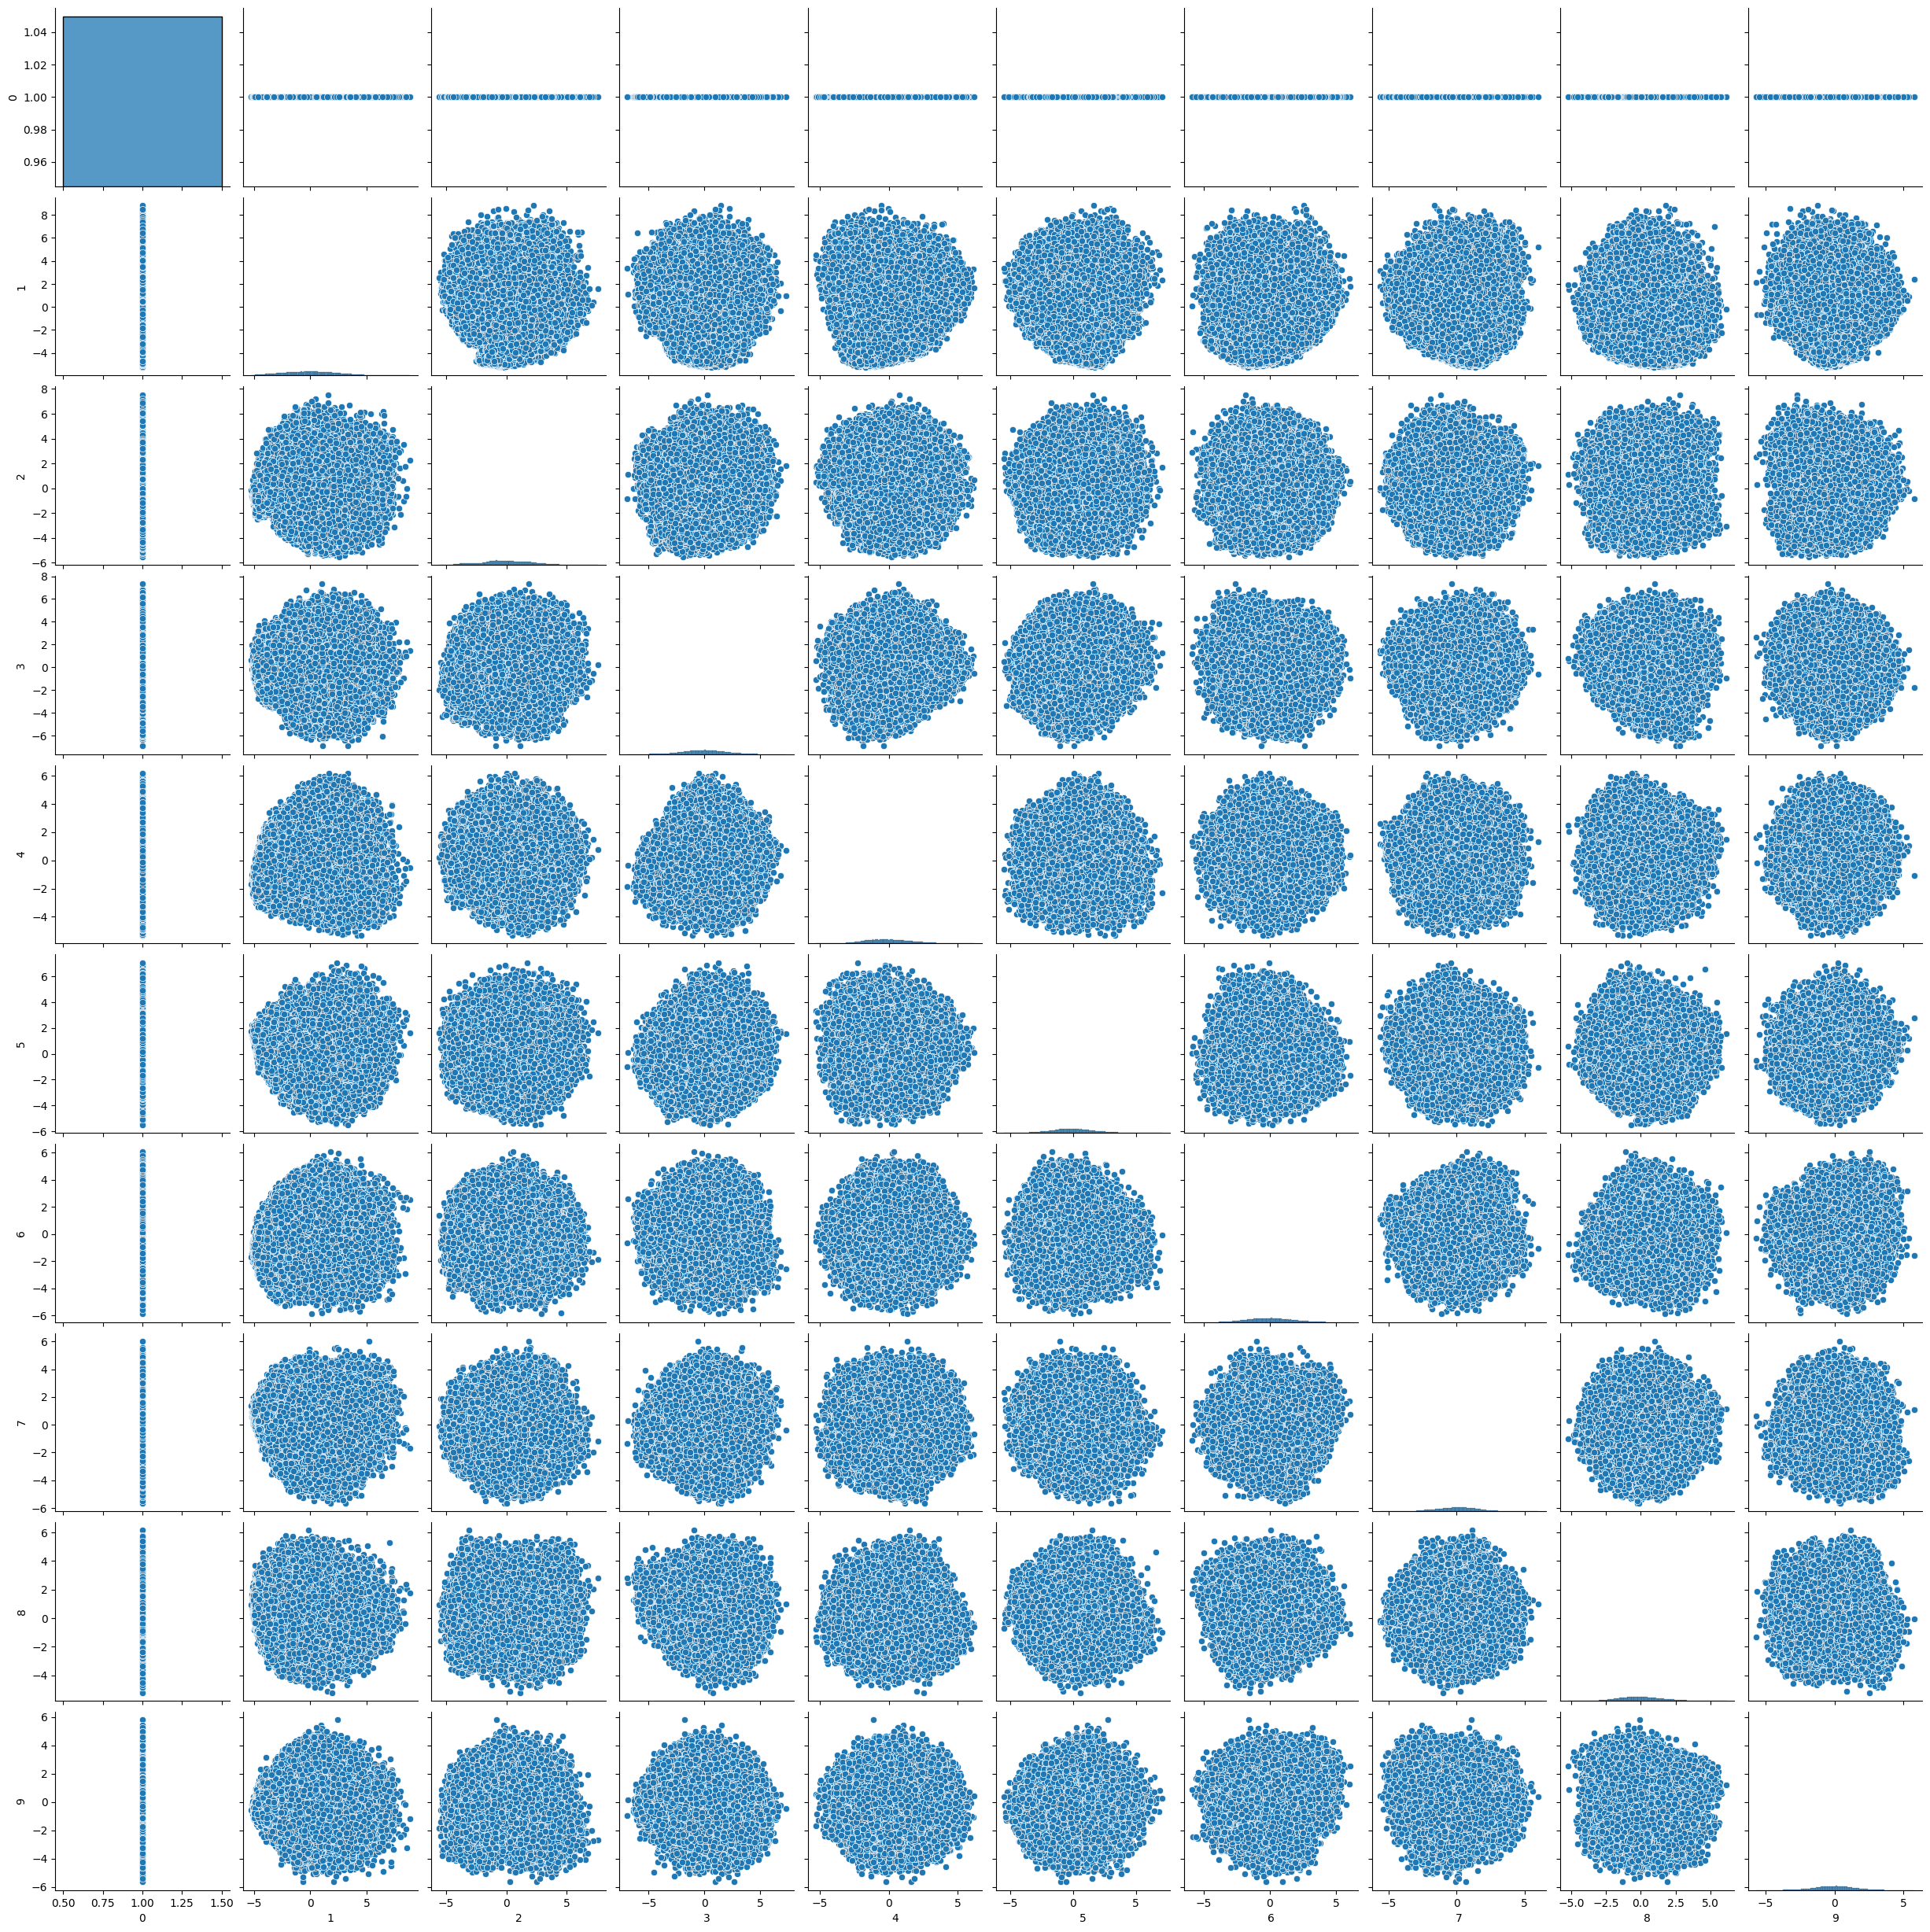

In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA

# Reduce the dimensionality first using PCA (e.g., reduce to 20 dimensions)
pca = PCA(n_components=20)
x_train_pca = pca.fit_transform(x_train.reshape(x_train.shape[0], -1))

# Now apply PolynomialFeatures to the reduced dataset
poly = PolynomialFeatures(degree=2, interaction_only=True)
interactions = poly.fit_transform(x_train_pca)

# Visualize the first 10 interactions using pairplot
sns.pairplot(pd.DataFrame(interactions).iloc[:, :10])  # Visualize the first 10 interactions
plt.show()


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version

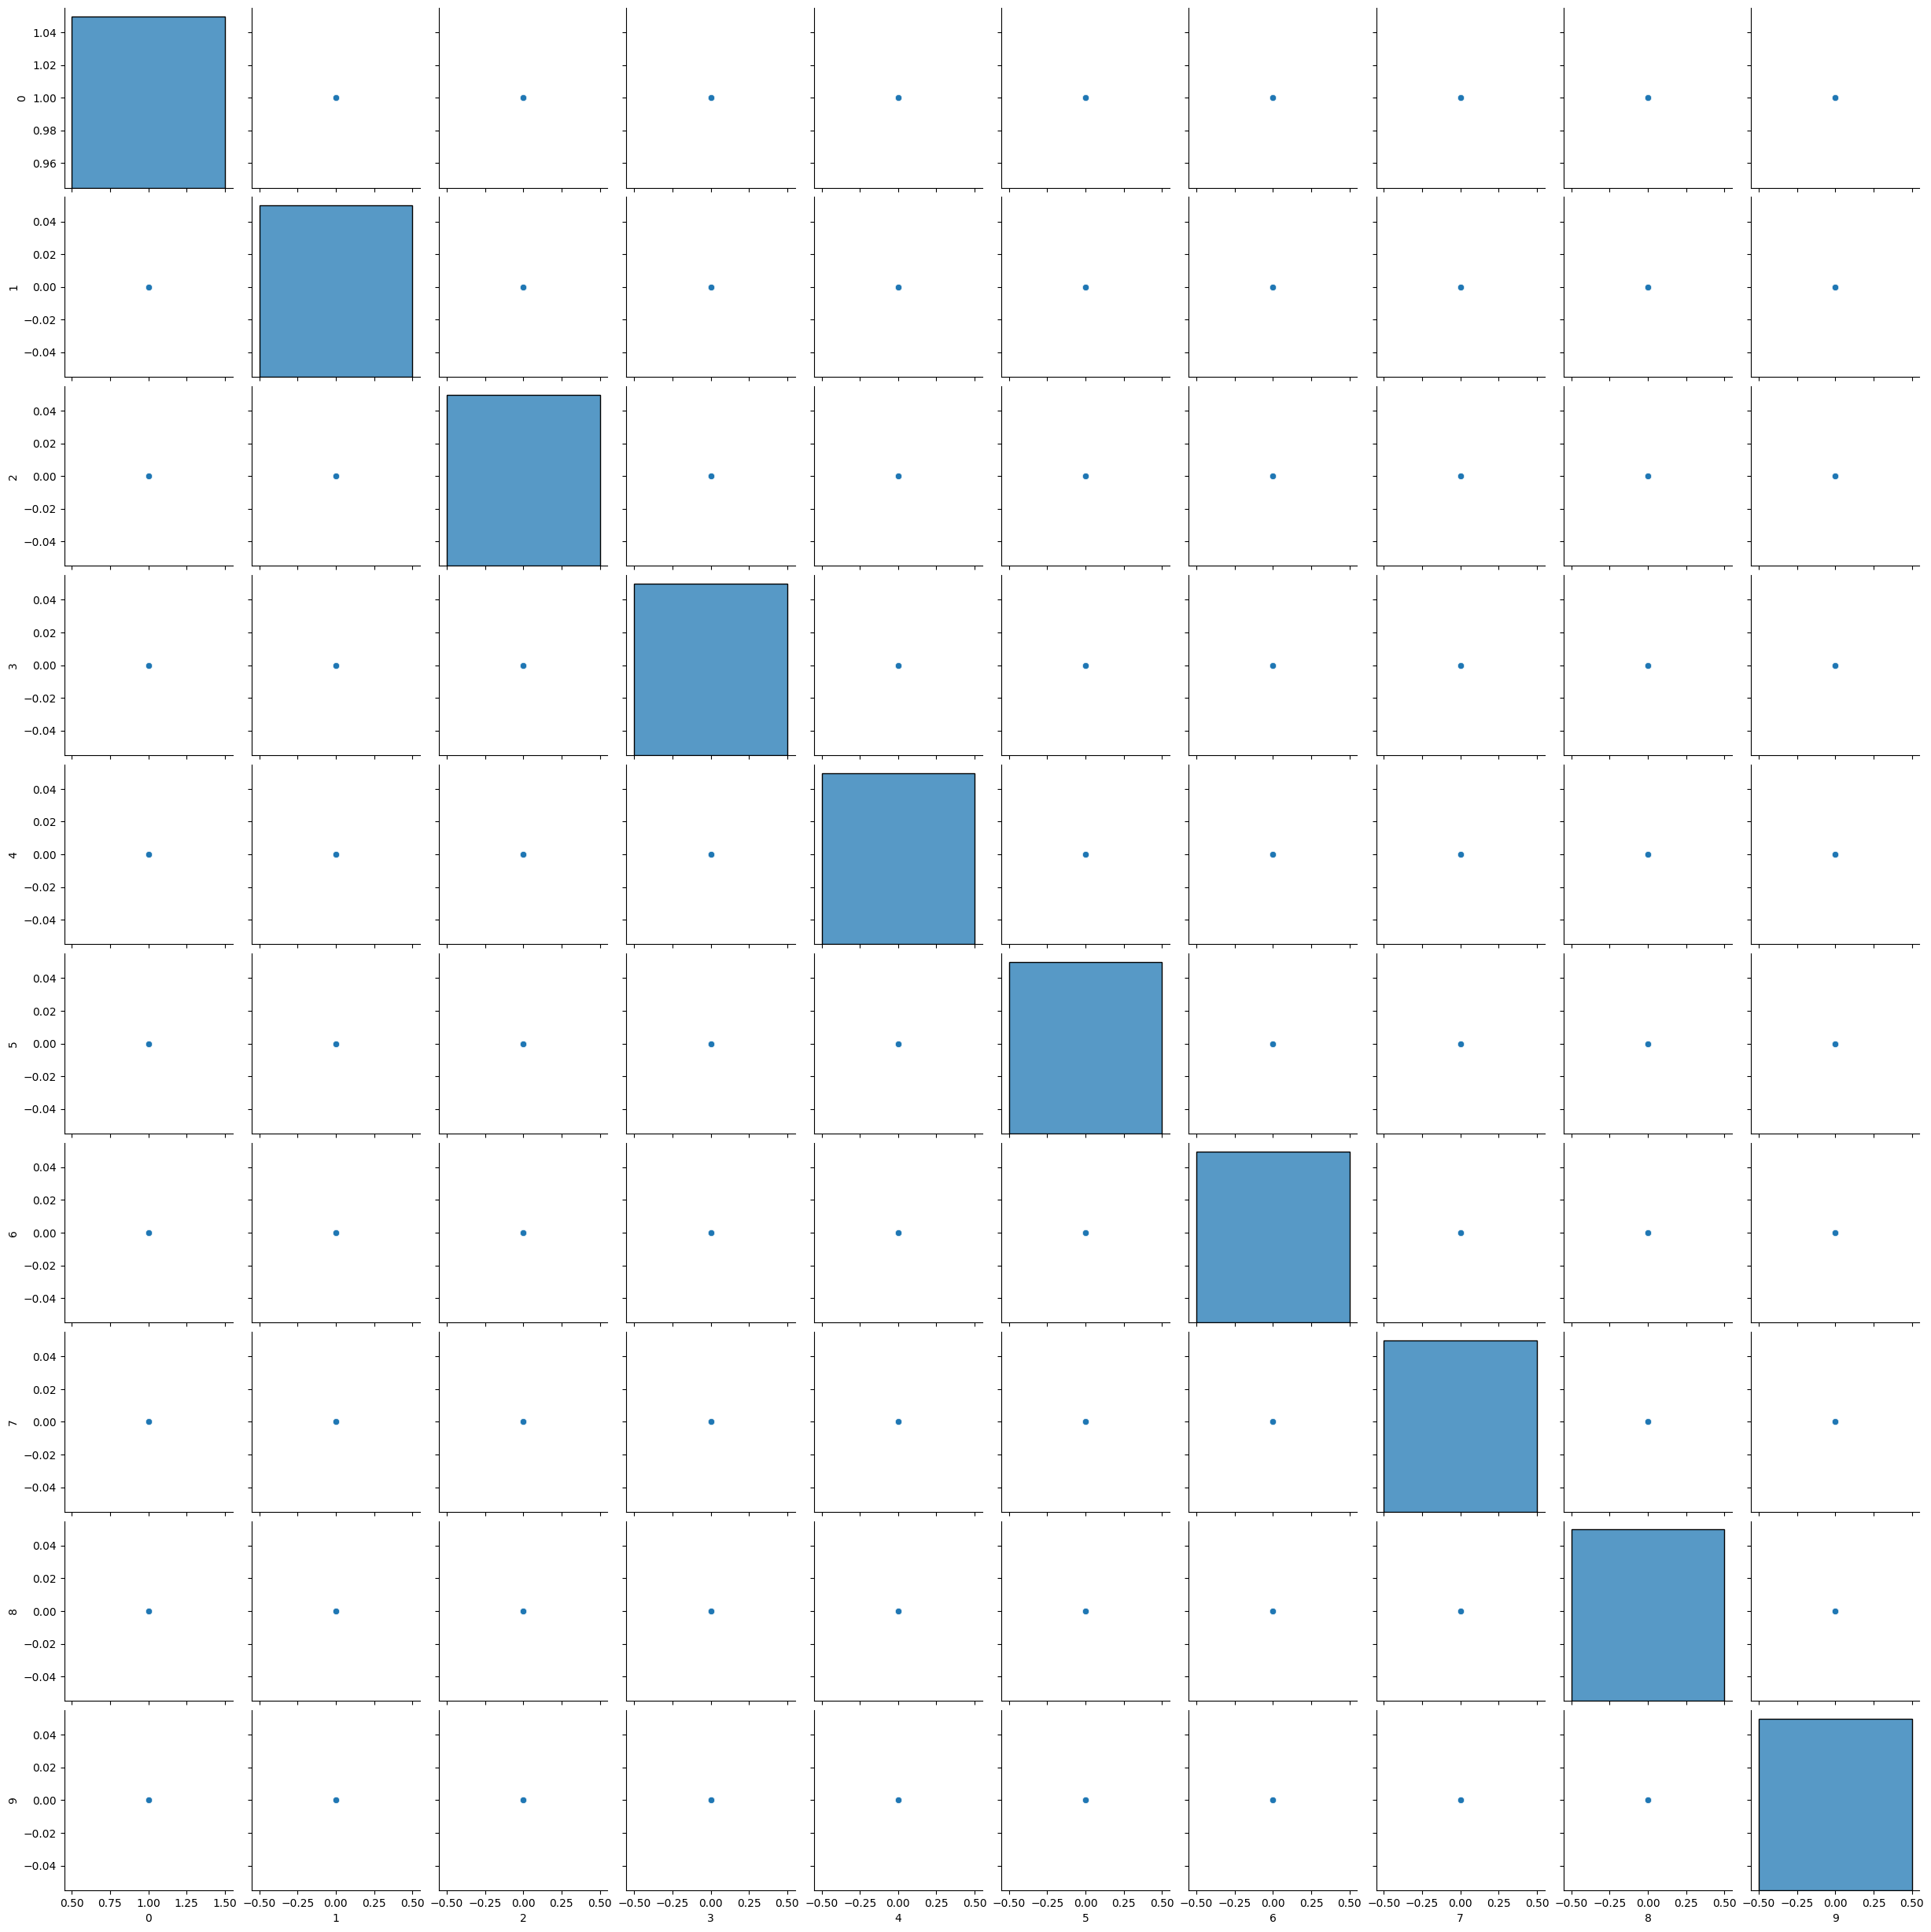

In [14]:
from sklearn.preprocessing import PolynomialFeatures

# Sample a subset of the data (e.g., 1000 samples)
x_train_sample = x_train[:1000].reshape(1000, -1)

# Apply PolynomialFeatures to the sample
poly = PolynomialFeatures(degree=2, interaction_only=True)
interactions = poly.fit_transform(x_train_sample)

# Visualize the first 10 interactions using pairplot
sns.pairplot(pd.DataFrame(interactions).iloc[:, :10])  # Visualize the first 10 interactions
plt.show()


In [15]:
# Detect and initialize the TPU
try:
    resolver = tf.distribute.cluster_resolver.TPUClusterResolver()  # Initialize TPU system
    tf.config.experimental_connect_to_cluster(resolver)
    tf.tpu.experimental.initialize_tpu_system(resolver)
    strategy = tf.distribute.TPUStrategy(resolver)
    print("Running on TPU")
except ValueError:
    strategy = tf.distribute.get_strategy()  # Fallback for CPU or GPU
    print("Running on CPU or GPU")

Running on CPU or GPU


In [16]:
# Model Building with Novelty

# Define a hybrid CNN + LSTM model
def build_hybrid_model():
    input_layer = tf.keras.layers.Input(shape=(28, 28, 1))
    
    # CNN Layers
    conv1 = tf.keras.layers.Conv2D(32, (3, 3), activation="relu")(input_layer)
    pool1 = tf.keras.layers.MaxPooling2D((2, 2))(conv1)
    conv2 = tf.keras.layers.Conv2D(64, (3, 3), activation="relu")(pool1)
    pool2 = tf.keras.layers.MaxPooling2D((2, 2))(conv2)
    flatten = tf.keras.layers.Flatten()(pool2)
    
    # LSTM layers
    lstm_input = tf.keras.layers.RepeatVector(10)(flatten)
    lstm_out = tf.keras.layers.LSTM(64, return_sequences=True)(lstm_input)
    lstm_out = tf.keras.layers.LSTM(32)(lstm_out)
    
    # Dense and Output layers
    dense = tf.keras.layers.Dense(128, activation="relu")(lstm_out)
    output = tf.keras.layers.Dense(47, activation="softmax")(dense)
    
    model = tf.keras.models.Model(inputs=input_layer, outputs=output)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    
    return model

# Instantiate the model
model = build_hybrid_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 1600)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 64)         │       426,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 467,759 (1.78 MB)

 Trainable params: 467,759 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Define CNN + LSTM Finite Automata
class HybridCNNLSTMFiniteAutomata:
    def __init__(self):
        self.states = ['q0', 'q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8']
        self.current_state = 'q0'
    
    def transition(self, input_data):
        if self.current_state == 'q0':
            print("Input Layer")
            self.current_state = 'q1'
        elif self.current_state == 'q1':
            print("Conv Layer 1 Activated (CNN)")
            self.current_state = 'q2'
        elif self.current_state == 'q2':
            print("Max Pooling 1 Activated (CNN)")
            self.current_state = 'q3'
        elif self.current_state == 'q3':
            print("Conv Layer 2 Activated (CNN)")
            self.current_state = 'q4'
        elif self.current_state == 'q4':
            print("Max Pooling 2 Activated (CNN)")
            self.current_state = 'q5'
        elif self.current_state == 'q5':
            print("Flatten Layer (Transition to LSTM)")
            self.current_state = 'q6'
        elif self.current_state == 'q6':
            print("LSTM Layer 1 Activated (LSTM)")
            self.current_state = 'q7'
        elif self.current_state == 'q7':
            print("LSTM Layer 2 Activated (LSTM)")
            self.current_state = 'q8'
        elif self.current_state == 'q8':
            print("Dense and Output Layers (Classification)")
        else:
            print("Invalid state transition")
    
    def classify(self, input_data):
        # Run through each layer (or state) of the Hybrid CNN + LSTM model
        for i in range(len(self.states)-1):
            self.transition(input_data)
        
        if self.current_state == 'q8':
            print("Input classified successfully!")

# Usage of the Hybrid CNN + LSTM Finite Automata
input_image_data = '/kaggle/input/single/41598_2022_7571_Fig1_HTML.png'  # Dummy input data for demonstration
cnn_lstm_fa = HybridCNNLSTMFiniteAutomata()
cnn_lstm_fa.classify(input_image_data)

Input Layer
Conv Layer 1 Activated (CNN)
Max Pooling 1 Activated (CNN)
Conv Layer 2 Activated (CNN)
Max Pooling 2 Activated (CNN)
Flatten Layer (Transition to LSTM)
LSTM Layer 1 Activated (LSTM)
LSTM Layer 2 Activated (LSTM)
Input classified successfully!


In [18]:
# Training the hybrid model
epochs = 25
batch_size = 256

# Train the model
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=epochs, batch_size=batch_size, verbose=1)


Epoch 1/25
353/353 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4498 - loss: 2.1672 - val_accuracy: 0.8037 - val_loss: 0.5958
Epoch 2/25
353/353 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8266 - loss: 0.5253 - val_accuracy: 0.8409 - val_loss: 0.4564
Epoch 3/25
353/353 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8576 - loss: 0.4110 - val_accuracy: 0.8545 - val_loss: 0.4091
Epoch 4/25
353/353 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8755 - loss: 0.3573 - val_accuracy: 0.8640 - val_loss: 0.3851
Epoch 5/25
353/353 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8878 - loss: 0.3134 - val_accuracy: 0.8671 - val_loss: 0.3768
Epoch 6/25
353/353 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8932 - loss: 0.2863 - val_accuracy: 0.8666 - val_loss: 0.3764
Epoch 7/25
353/353 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8991 - loss: 0.2720 - val_accuracy: 0.8741 - val_loss: 0.3667
Epoch 8/25
353/353 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9052 - loss: 0.2505 - val_accu

In [19]:
# Extract training and validation accuracy
train_accuracy = history.history['accuracy']
# Print the final training accuracy
print(f"Final Training Accuracy: {train_accuracy[-1]:.4f}")


Final Training Accuracy: 0.9555


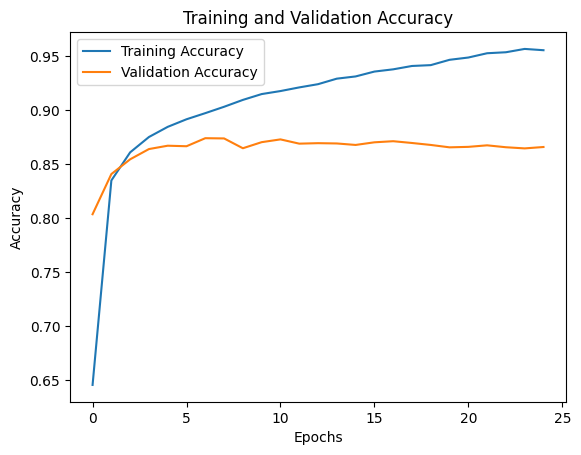

In [20]:
# Plot Training and Validation Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

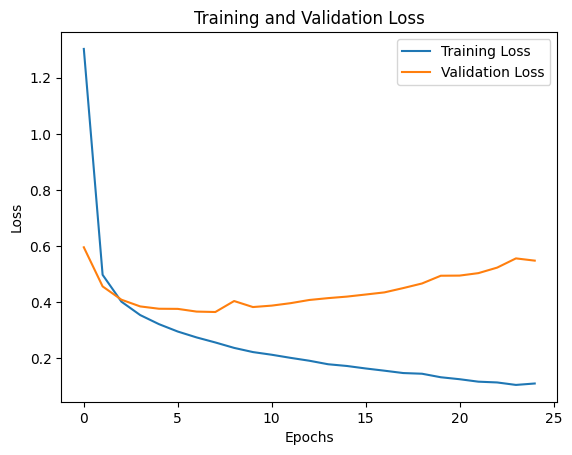

In [21]:
# Plot Training and Validation Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [22]:
# Assuming the model has already been built and trained

# Save the hybrid model
model.save('hybrid_cnn_lstm_model.h5')
print("Model saved to hybrid_cnn_lstm_model.h5")

# Later, when you need to load the model:
from keras.models import load_model

# Load the saved model
loaded_model = load_model('hybrid_cnn_lstm_model.h5')
print("Model loaded successfully")




Model saved to hybrid_cnn_lstm_model.h5
Model loaded successfully


In [23]:
!pip install spellchecker pytesseract pyspellchecker textblob

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning:

os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 46.7 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 74.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.1 MB/s eta 0:00:00
  Created wheel for spellchecker: filename=spellchecker-0.4-py3-none-any.whl size=3966500 sha256=8b3943eee4bdf8e0884568f739593e398bcbc87703d12a85d95b915780bd1b19
  Stored in directory: /root/.cache/pip/wheels/6c/90/c3/eac248d8755b2a7343487a2087b4b29ad98f388c3c8c69c286
  Created wheel for inexactsearch: filename=inexactsearch-1.0.2-py3-none-any.whl size=7123 sha256=fbc652aeca3da57872aa520031e84674c38f52542a109e020f422b7a08f4cfc2
  Stored in directory: /root/.cache/pip/wheels/63/19/2c/5e9f447f2533d457a1167c3e553f235e232b8a639e3f5fafab
  Created wheel for silpa_common: filename=

In [24]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
from keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from textblob import TextBlob
import pytesseract
import easyocr
import logging
import time

logging.basicConfig(level=logging.INFO)

class OCRProcessorFA:
    def __init__(self, model_paths, medical_dict_path):
        self.current_state = 'q0'  # Initial state
        self.models = self.load_models(model_paths)
        self.char_mapping, self.medical_dict = self.load_medical_dict(medical_dict_path)
        self.datagen = self.setup_datagen()
        self.reader = easyocr.Reader(['en'], gpu=False)
    
    def transition(self, next_state):
        """Transition to the next state."""
        logging.info(f"Transitioning from {self.current_state} to {next_state}")
        self.current_state = next_state

    def load_models(self, model_paths):
        """Load models from given paths."""
        models = []
        if self.current_state == 'q0':
            for model_path in model_paths:
                if not os.path.exists(model_path):
                    raise FileNotFoundError(f"Model file not found at path: {model_path}")
                model = load_model(model_path)
                model.summary()  # Print model summary for verification
                models.append(model)
            self.transition('q1')
        return models

    def load_medical_dict(self, medical_dict_path):
        """Load medical dictionary for character mapping and terms."""
        if self.current_state != 'q1':
            logging.error("Models not loaded yet. Cannot load medical dictionary.")
            return {}, set()

        if not os.path.exists(medical_dict_path):
            raise FileNotFoundError(f"Medical dictionary not found at path: {medical_dict_path}")
        
        char_mapping = {}
        medical_terms = set()
        
        with open(medical_dict_path, 'r') as file:
            for line in file:
                parts = line.strip().split()
                if len(parts) == 2:
                    key, value = parts
                    char_mapping[int(key)] = chr(int(value))
                elif len(parts) == 1:
                    medical_terms.add(parts[0].lower())
                else:
                    logging.warning(f"Invalid line in medical dictionary: {line.strip()}")
        
        self.transition('q2')
        return char_mapping, medical_terms

    def setup_datagen(self):
        """Set up image data generator for advanced augmentation."""
        return ImageDataGenerator(
            rotation_range=30,
            width_shift_range=0.25,
            height_shift_range=0.25,
            shear_range=0.3,
            zoom_range=0.25,
            brightness_range=[0.8, 1.2],  # Adjust brightness
            fill_mode='nearest'
        )

    def augment_image(self, image):
        """Augment image using data generator."""
        image = image.reshape((1, 28, 28, 1))  # Reshape to fit datagen's expected input
        it = self.datagen.flow(image, batch_size=1)
        batch = it[0]
        image_augmented = batch[0].astype('float32')
        return image_augmented

    def preprocess_image(self, image_path):
        """Preprocess image for OCR with contrast enhancement and noise reduction."""
        if self.current_state != 'q2':
            logging.error("Medical dictionary not loaded yet. Cannot preprocess image.")
            return None, None

        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Image not found at path: {image_path}")

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise FileNotFoundError(f"Unable to read image at path: {image_path}")

        # Apply CLAHE for contrast enhancement
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        image_clahe = clahe.apply(image)

        # Apply Non-Local Means Denoising for noise reduction
        image_denoised = cv2.fastNlMeansDenoising(image_clahe, None, 30, 7, 21)

        # Adaptive thresholding for better results with handwriting
        adaptive_thresh = cv2.adaptiveThreshold(image_denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                                cv2.THRESH_BINARY_INV, 11, 2)

        self.transition('q3')
        return image, adaptive_thresh

    def segment_letters(self, image):
        """Segment letters from the image using connected components analysis."""
        if self.current_state != 'q3':
            logging.error("Image not preprocessed yet. Cannot segment letters.")
            return []

        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
        dilated = cv2.dilate(image, kernel, iterations=1)
        eroded = cv2.erode(dilated, kernel, iterations=1)

        contours, _ = cv2.findContours(eroded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        letter_images = []
        for contour in contours:
            x, y, w, h = cv2.boundingRect(contour)
            aspect_ratio = h / float(w)
            if 10 < w < 100 and 10 < h < 100 and 0.2 < aspect_ratio < 5:
                letter_image = image[y:y+h, x:x+w]
                letter_images.append((x, y, w, h, letter_image))

        logging.info(f"Found {len(letter_images)} letters")
        self.transition('q4')
        return sorted(letter_images, key=lambda x: x[0])

    def predict_letter(self, letter_image):
        """Predict letter from the segmented image and return confidence score."""
        if self.current_state != 'q4':
            logging.error("Letters not segmented yet. Cannot predict letters.")
            return '?', 0.0

        if letter_image.size == 0:
            logging.warning("Empty letter image encountered.")
            return '?', 0.0
        
        letter_image_resized = cv2.resize(letter_image, (28, 28))
        letter_image_resized = self.augment_image(letter_image_resized)
        letter_image_array = img_to_array(letter_image_resized) / 255.0
        letter_image_array = np.expand_dims(letter_image_array, axis=0)

        predictions = np.array([model.predict(letter_image_array) for model in self.models])
        
        # Dynamically create weights based on the number of models
        num_models = len(self.models)
        weights = [1 / num_models] * num_models  # Equal weights for all models
        
        weighted_predictions = np.average(predictions, axis=0, weights=weights)
        predicted_index = np.argmax(weighted_predictions)
        confidence = np.max(weighted_predictions)  # Confidence score for the prediction

        return self.char_mapping.get(predicted_index, '?'), confidence

    def predict_letters(self, letter_images):
        """Predict letters for all segmented images and calculate overall confidence."""
        if self.current_state != 'q4':
            logging.error("Letters not segmented yet. Cannot predict letters.")
            return [], 0.0

        character_positions = []
        total_confidence = 0.0
        for i, (x, y, w, h, letter_image) in enumerate(letter_images):
            predicted_letter, confidence = self.predict_letter(letter_image)
            logging.info(f'Letter {predicted_letter}: x={x}, y={y}, w={w}, h={h}, confidence={confidence:.2f}')
            total_confidence += confidence
            character_positions.append((x, x + w, predicted_letter))
        
        predicted_letters = self.insert_spaces(character_positions)
        average_confidence = total_confidence / len(letter_images) if letter_images else 0.0
        logging.info(f'Average confidence score: {average_confidence:.2f}')
        self.transition('q5')
        return predicted_letters, average_confidence

    def insert_spaces(self, character_positions):
        """Insert spaces between predicted letters based on gaps."""
        if not character_positions:
            return []

        gaps = [character_positions[i + 1][0] - character_positions[i][1] for i in range(len(character_positions) - 1)]
        if not gaps:
            return [char for _, _, char in character_positions]

        average_gap = np.mean(gaps)
        std_gap = np.std(gaps)

        space_threshold = average_gap + 0.5 * std_gap
        punctuation_threshold = average_gap + 1.5 * std_gap

        predicted_letters = []
        previous_end = character_positions[0][1]

        for i, (start, end, letter) in enumerate(character_positions):
            if i > 0:
                gap = start - previous_end
                if gap > punctuation_threshold:
                    logging.info(f'Inserting punctuation (punctuation threshold) at gap {gap}')
                    predicted_letters.append(' ')
                elif gap > space_threshold:
                    logging.info(f'Inserting space (space threshold) at gap {gap}')
                    predicted_letters.append(' ')
            predicted_letters.append(letter)
            previous_end = end

        return predicted_letters

    def post_process_text(self, text):
        """Correct spelling using TextBlob for contextual correction."""
        blob = TextBlob(text)
        corrected_text = str(blob.correct())  # Automatically correct spelling
        return corrected_text

    def visualize_ocr_process(self, image_path):
        """Visualize the OCR process and results with confidence score aggregation."""
        start_time = time.time()
        original_image, preprocessed_image = self.preprocess_image(image_path)
    
        # Tesseract OCR
        custom_config = r'--oem 3 --psm 6 -l eng+osd'  # Optimizing Tesseract config
        tesseract_text = pytesseract.image_to_string(preprocessed_image, config=custom_config)
        logging.info(f'Tesseract Text: {tesseract_text}')
    
        # EasyOCR
        easyocr_result = self.reader.readtext(preprocessed_image)
        easyocr_text = ' '.join([item[1] for item in easyocr_result])
        logging.info(f'EasyOCR Text: {easyocr_text}')
    
        # Model OCR
        letter_images = self.segment_letters(preprocessed_image)
        self.show_segmented_letters(preprocessed_image, letter_images)
        model_letters, avg_confidence = self.predict_letters(letter_images)
        model_text = ''.join(model_letters)
        logging.info(f'Model Text: {model_text}')
        logging.info(f'Average Model Confidence: {avg_confidence:.2f}')
    
        # Combine Results
        final_text = self.combine_results(tesseract_text, model_text, easyocr_text)
        corrected_text = self.post_process_text(final_text)
        end_time = time.time()
        logging.info(f'Final Corrected Text: {corrected_text}')
        logging.info(f'Time taken: {end_time - start_time:.2f} seconds')

        # Print the final corrected text and average confidence score
        print(f'Predicted Text: {corrected_text}')
        print(f'Average Confidence Score: {avg_confidence:.2f}')
        self.show_images(original_image, preprocessed_image, letter_images)

    def show_images(self, original_image, preprocessed_image, letter_images):
        """Display the original, preprocessed, and segmented images."""
        fig, ax = plt.subplots(1, 3, figsize=(30, 10))
        ax[0].imshow(original_image, cmap='gray')
        ax[0].set_title('Original Image')
        ax[0].axis('off')

        ax[1].imshow(preprocessed_image, cmap='gray')
        ax[1].set_title('Preprocessed Image')
        ax[1].axis('off')

        for (x, y, w, h, _) in letter_images:
            cv2.rectangle(original_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
        ax[2].imshow(original_image, cmap='gray')
        ax[2].set_title('Processed Image with Bounding Boxes')
        ax[2].axis('off')

        plt.tight_layout()
        plt.show()

    def show_segmented_letters(self, preprocessed_image, letter_images):
        """Visualize segmented letters."""
        fig, ax = plt.subplots(1, len(letter_images), figsize=(20, 10))
        for i, (x, y, w, h, letter_image) in enumerate(letter_images):
            ax[i].imshow(letter_image, cmap='gray')
            ax[i].set_title(f'Letter {i+1}')
            ax[i].axis('off')
        plt.tight_layout()
        plt.show()

    def combine_results(self, tesseract_text, model_text, easyocr_text):
        """Combine Tesseract, EasyOCR, and custom model OCR results."""
        combined_text = max([tesseract_text, model_text, easyocr_text], key=len)
        return combined_text




Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 1600)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 64)         │       426,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 467,761 (1.78 MB)

 Trainable params: 467,759 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

/opt/conda/lib/python3.10/site-packages/easyocr/detection.py:78: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.

/opt/conda/lib/python3.10/site-packages/easyocr/recognition.py

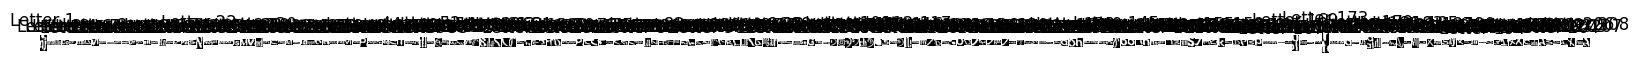

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━

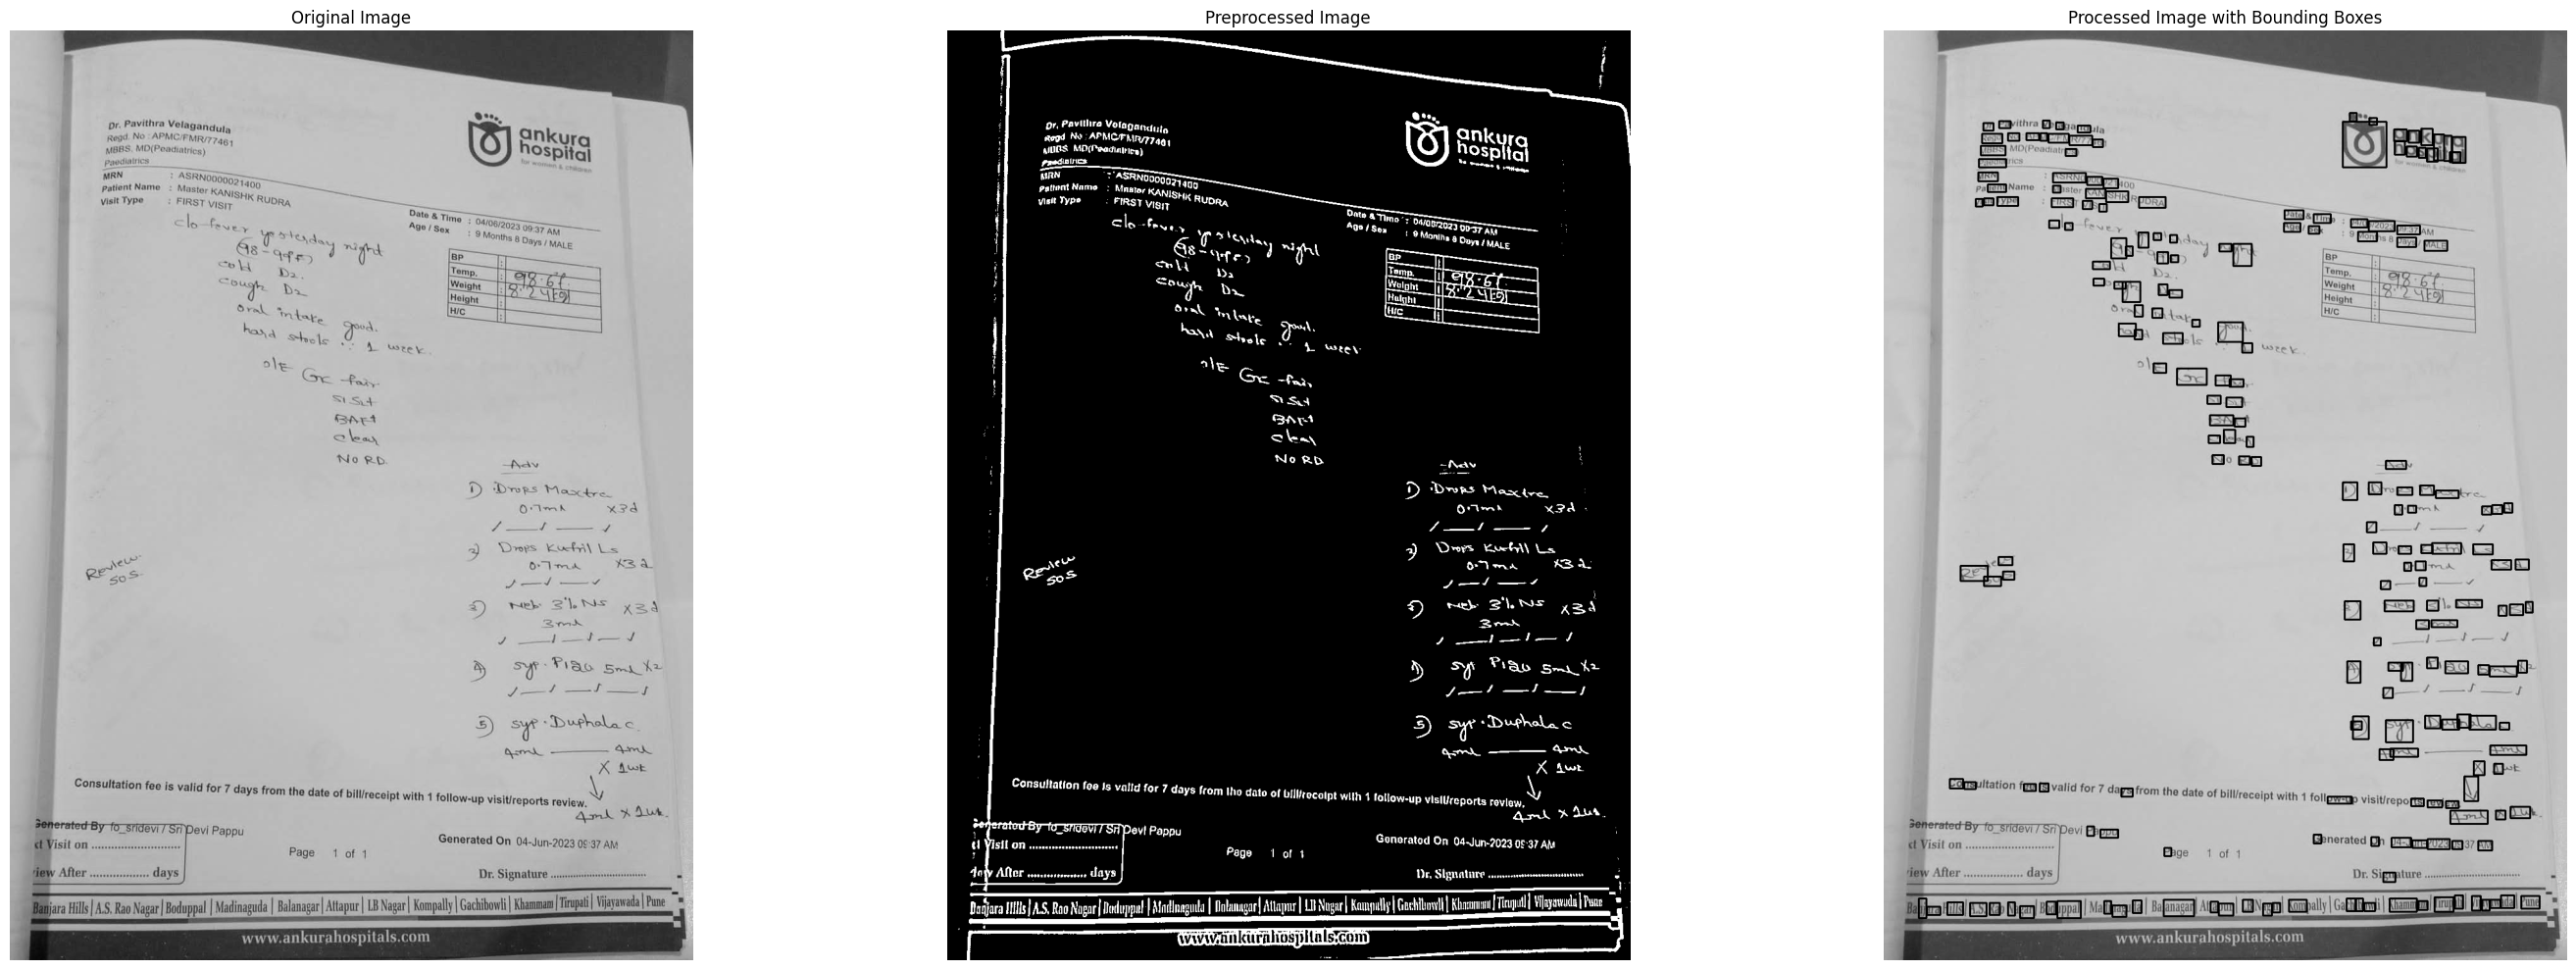

In [25]:
# Usage example
ocr_processor = OCRProcessorFA(
    model_paths=['hybrid_cnn_lstm_model.h5'],  # Assuming the model has been saved earlier
    medical_dict_path='/kaggle/input/medicine-text/test.dat'  # Path to your medical dictionary
)

# Visualize the OCR process for a given image (replace with your actual image path)
ocr_processor.visualize_ocr_process('/kaggle/input/dataset-pre/IMG-20240528-WA0025.jpg')